# F1-RaceIQ-Suite: Regression — Logistic Regression



## Step 1 — Import Libraries



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              roc_curve)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2 — Load the Cleaned Dataset



In [2]:
df = pd.read_csv('cleaned_f1_data.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 6939 rows, 19 columns


,Season,Round,Race Name,Date,Circuit,Country,Latitude,Longitude,Driver,Driver Nationality,Driver Age,Constructor,Grid Position,Race Position,Points Earned,Fastest Lap (s),Fastest Lap Rank,Laps Completed,Status
0,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Nino Farina,Italian,44,Alfa Romeo,1,1,9.0,90.239026,-1,70,Finished
1,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Reg Parnell,British,39,Alfa Romeo,4,3,4.0,90.239026,-1,70,Finished
2,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Yves Cabantous,French,46,Talbot-Lago,6,4,3.0,90.239026,-1,68,+2 Laps
3,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Louis Rosier,French,45,Talbot-Lago,9,5,2.0,90.239026,-1,68,+2 Laps
4,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Bob Gerard,British,36,ERA,13,6,0.0,90.239026,-1,67,+3 Laps


## Step 3 — Identify Categorical and Numerical Columns



In [3]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", list(categorical_columns))

numeric_columns = df.select_dtypes(include=['number']).columns
print("Numeric Columns:", list(numeric_columns))

Categorical Columns: ['Race Name', 'Date', 'Circuit', 'Country', 'Driver', 'Driver Nationality', 'Constructor', 'Status']
Numeric Columns: ['Season', 'Round', 'Latitude', 'Longitude', 'Driver Age', 'Grid Position', 'Race Position', 'Points Earned', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed']


## Step 4 — Drop Irrelevant Columns


In [4]:
to_drop = ['Season', 'Round', 'Race Name', 'Date', 'Country',
           'Driver Nationality', 'Driver', 'Points Earned',
           'Latitude', 'Longitude']

df = df.drop(columns=to_drop, errors='ignore')
print("Remaining columns:", list(df.columns))
print("Shape after dropping:", df.shape)

Remaining columns: ['Circuit', 'Driver Age', 'Constructor', 'Grid Position', 'Race Position', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed', 'Status']
Shape after dropping: (6939, 9)


## Step 5 — Define the Target Variable



In [5]:
df['Position_Category'] = (df['Race Position'] <= 10).astype(int)
df = df.drop(['Race Position'], axis=1)

print("Target variable distribution:")
print(df['Position_Category'].value_counts())
total = len(df)
points = df['Position_Category'].sum()
print(f"\nClass balance: {points/total*100:.1f}% Points, {(total-points)/total*100:.1f}% No Points")

Target variable distribution:
Position_Category
0    3590
1    3349
Name: count, dtype: int64

Class balance: 48.3% Points, 51.7% No Points


## Step 6 — Encode Categorical Columns



In [6]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

categories_list = [df[col].unique().tolist() for col in categorical_cols]
encoder = OrdinalEncoder(categories=categories_list)
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

print("Encoding complete.")
df.head()

Categorical columns to encode: ['Circuit', 'Constructor', 'Status']
Encoding complete.


,Circuit,Driver Age,Constructor,Grid Position,Fastest Lap (s),Fastest Lap Rank,Laps Completed,Status,Position_Category
0,0.0,44,0.0,1,90.239026,-1,70,0.0,1
1,0.0,39,0.0,4,90.239026,-1,70,0.0,1
2,0.0,46,1.0,6,90.239026,-1,68,1.0,1
3,0.0,45,1.0,9,90.239026,-1,68,1.0,1
4,0.0,36,2.0,13,90.239026,-1,67,2.0,1


## Step 7 — Feature Engineering (Binary Features)



In [7]:
df['Grid Position Binary'] = (df['Grid Position'] <= 10).astype(int)
df['Driver Age Binary'] = (df['Driver Age'] > 30).astype(int)
df['Laps Completed Binary'] = (df['Laps Completed'] > 50).astype(int)

df = df.drop(['Grid Position', 'Driver Age', 'Laps Completed'], axis=1)
print("Binary features created.")
print("Columns now:", list(df.columns))

Binary features created.
Columns now: ['Circuit', 'Constructor', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Status', 'Position_Category', 'Grid Position Binary', 'Driver Age Binary', 'Laps Completed Binary']


## Step 8 — Train/Test Split (80/20) + Feature Scaling


In [8]:
X = df.drop(['Position_Category'], axis=1)
y = df['Position_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Features:     {X_train.shape[1]} columns")
print(f"\nFeature names: {list(X.columns)}")

Training set: 5551 rows
Test set:     1388 rows
Features:     8 columns

Feature names: ['Circuit', 'Constructor', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Status', 'Grid Position Binary', 'Driver Age Binary', 'Laps Completed Binary']


## Step 10 — Model 1: Logistic Regression (Default)



In [9]:
lr_model_1 = LogisticRegression(max_iter=1000, random_state=42)
lr_model_1.fit(X_train_scaled, y_train)
y_pred_1 = lr_model_1.predict(X_test_scaled)

print("=" * 50)
print("MODEL 1 — Logistic Regression (Default lbfgs)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_1):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_1):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_1):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_model_1.predict_proba(X_test_scaled)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_1, target_names=['No Points', 'Points']))

MODEL 1 — Logistic Regression (Default lbfgs)
Accuracy:  0.8329
Precision: 0.8101
Recall:    0.8470
F1 Score:  0.8281
ROC-AUC:   0.8972

Classification Report:
              precision    recall  f1-score   support

   No Points       0.86      0.82      0.84       728
      Points       0.81      0.85      0.83       660

    accuracy                           0.83      1388
   macro avg       0.83      0.83      0.83      1388
weighted avg       0.83      0.83      0.83      1388



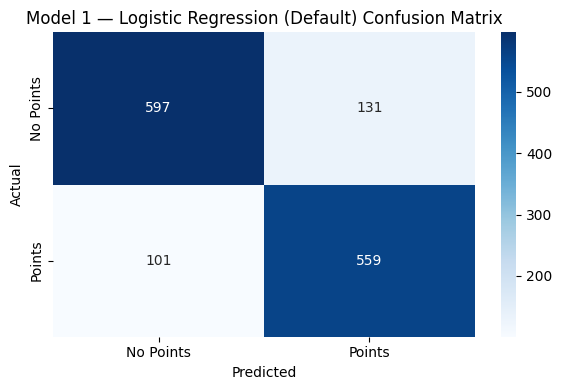

In [10]:
cm1 = confusion_matrix(y_test, y_pred_1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model 1 — Logistic Regression (Default) Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 11 — Model 2: Logistic Regression (saga + L1 Regularisation)


In [11]:
lr_model_2 = LogisticRegression(solver='saga', penalty='l1', C=1.0,
                                 max_iter=1000, random_state=42)
lr_model_2.fit(X_train_scaled, y_train)
y_pred_2 = lr_model_2.predict(X_test_scaled)

print("=" * 50)
print("MODEL 2 — Logistic Regression (saga + L1) — Best Model")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_2):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_2):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_model_2.predict_proba(X_test_scaled)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_2, target_names=['No Points', 'Points']))

MODEL 2 — Logistic Regression (saga + L1) — Best Model
Accuracy:  0.8336
Precision: 0.8104
Recall:    0.8485
F1 Score:  0.8290
ROC-AUC:   0.8972

Classification Report:
              precision    recall  f1-score   support

   No Points       0.86      0.82      0.84       728
      Points       0.81      0.85      0.83       660

    accuracy                           0.83      1388
   macro avg       0.83      0.83      0.83      1388
weighted avg       0.83      0.83      0.83      1388



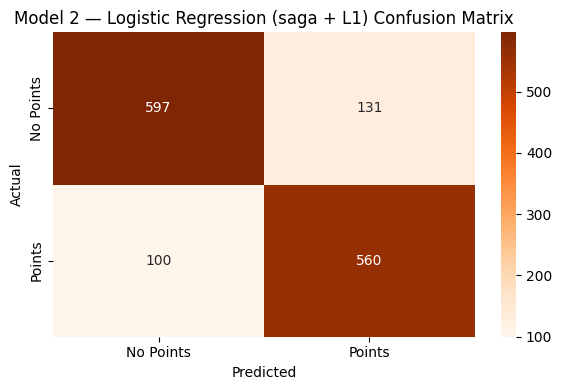

In [12]:
cm2 = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model 2 — Logistic Regression (saga + L1) Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 12 — Feature Coefficients ( Model 2)



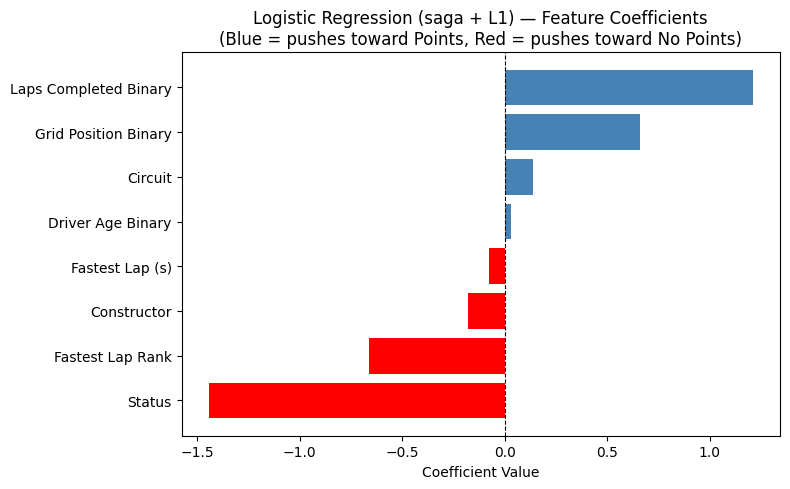


Coefficient values:
              Feature  Coefficient
               Status    -1.443720
     Fastest Lap Rank    -0.661667
          Constructor    -0.177184
      Fastest Lap (s)    -0.075479
    Driver Age Binary     0.030629
              Circuit     0.135992
 Grid Position Binary     0.661563
Laps Completed Binary     1.211078


In [13]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model_2.coef_[0]
}).sort_values('Coefficient', ascending=True)

colors = ['red' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression (saga + L1) — Feature Coefficients\n(Blue = pushes toward Points, Red = pushes toward No Points)')
plt.tight_layout()
plt.show()

print("\nCoefficient values:")
print(coef_df.to_string(index=False))

## Step 13 — ROC Curve (Both Models)


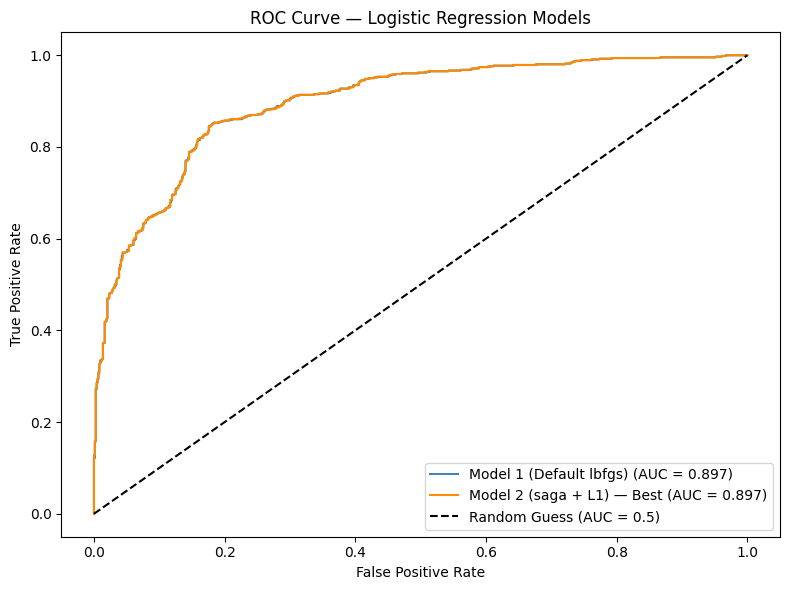

In [14]:
plt.figure(figsize=(8, 6))

for model, name, color in [
    (lr_model_1, 'Model 1 (Default lbfgs)', 'steelblue'),
    (lr_model_2, 'Model 2 (saga + L1) — Best', 'darkorange')
]:
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 14 — Cross Validation (Best Model — Model 2)



5-Fold Cross Validation Results (Best Model — saga + L1):
Fold scores: [0.7622 0.7731 0.8581 0.8638 0.8335]
Mean accuracy: 0.8181
Std deviation: 0.0426


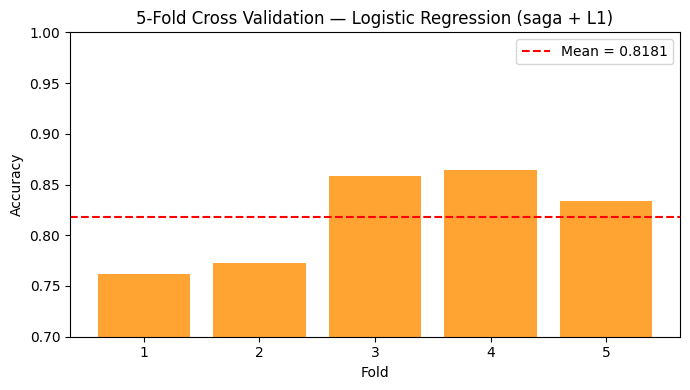

In [15]:
cv_scores = cross_val_score(lr_model_2,
                             scaler.fit_transform(X),
                             y, cv=5, scoring='accuracy')

print("5-Fold Cross Validation Results (Best Model — saga + L1):")
print(f"Fold scores: {cv_scores.round(4)}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")
print(f"Std deviation: {cv_scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='darkorange', alpha=0.8)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross Validation — Logistic Regression (saga + L1)')
plt.legend()
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

## Step 15 — Model Comparison


In [16]:
results = pd.DataFrame({
    'Model': ['LR Default (lbfgs)', 'LR saga + L1 (Best)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_1),
        accuracy_score(y_test, y_pred_2)
    ],
    'Precision': [
        precision_score(y_test, y_pred_1),
        precision_score(y_test, y_pred_2)
    ],
    'Recall': [
        recall_score(y_test, y_pred_1),
        recall_score(y_test, y_pred_2)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_1),
        f1_score(y_test, y_pred_2)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_model_1.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, lr_model_2.predict_proba(X_test_scaled)[:,1])
    ]
})

print(results.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
 LR Default (lbfgs)  0.832853   0.810145 0.846970  0.828148 0.897214
LR saga + L1 (Best)  0.833573   0.810420 0.848485  0.829016 0.897208


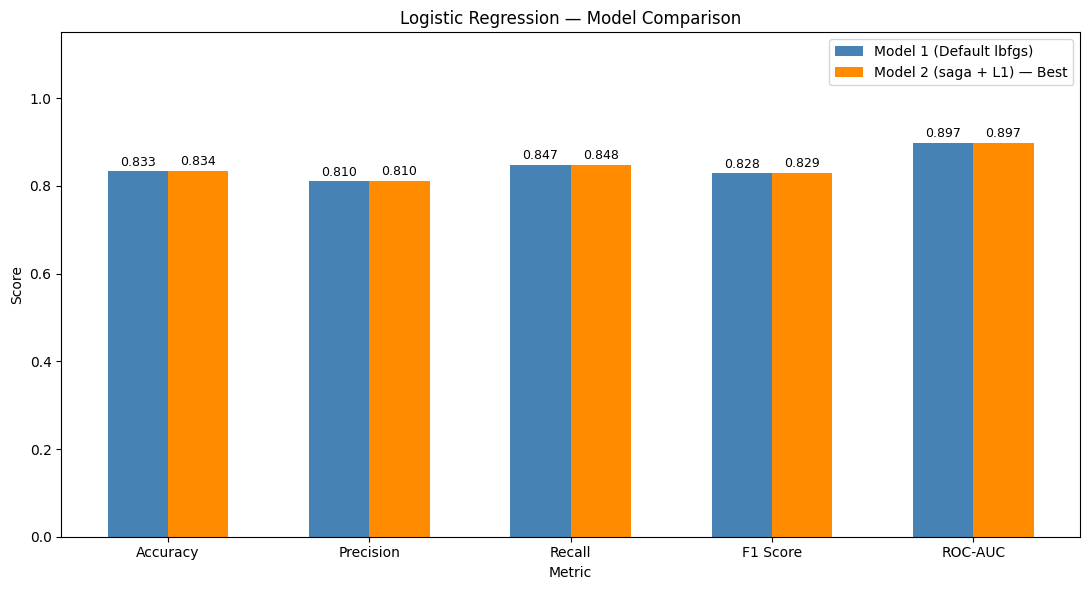

In [17]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, results.iloc[0][metrics], width,
               label='Model 1 (Default lbfgs)', color='steelblue')
bars2 = ax.bar(x + width/2, results.iloc[1][metrics], width,
               label='Model 2 (saga + L1) — Best', color='darkorange')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression — Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=9)
plt.tight_layout()
plt.show()